In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

### Sigmoid Function

In [2]:
def sigmoid(x):
    return 1 / (1+(math.e**(-x)))

In [3]:
x = np.array(list(range(-16, 17)))
y = sigmoid(x)
print(sum(y), min(y), max(y))

16.500000000000004 1.1253516205509509e-07 0.9999998874648379


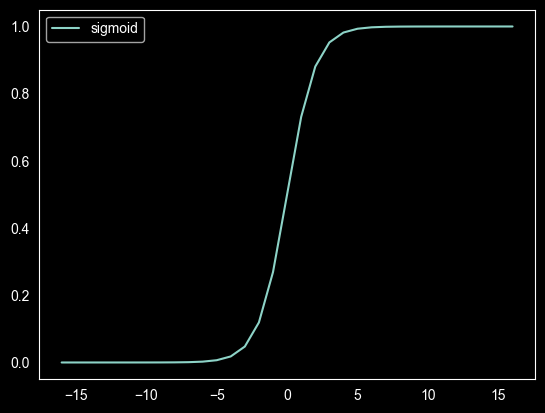

In [4]:
plt.plot(x, y, label="sigmoid")
plt.legend()
plt.grid()
plt.show()

### Cost Function - LogLoss

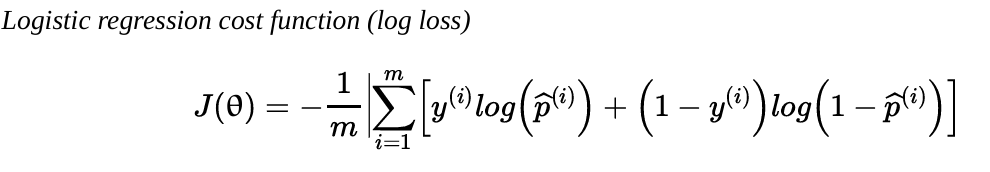

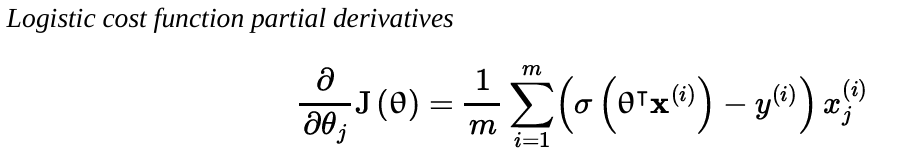

### Load Data - Iris Flower

In [7]:
iris = load_iris(as_frame=True)
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [12]:
iris.target

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [13]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [17]:
iris.data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

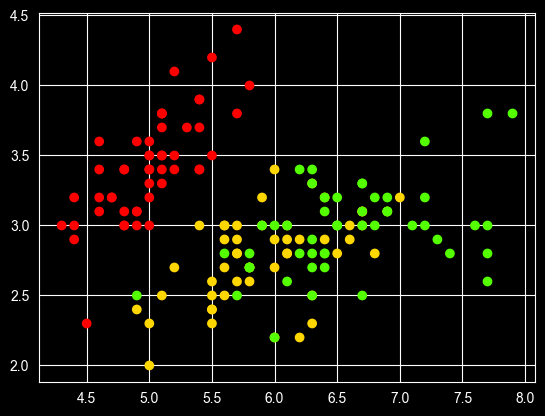

In [40]:
plt.scatter(iris.data["sepal length (cm)"], iris.data["sepal width (cm)"], c=iris.target, cmap="prism")

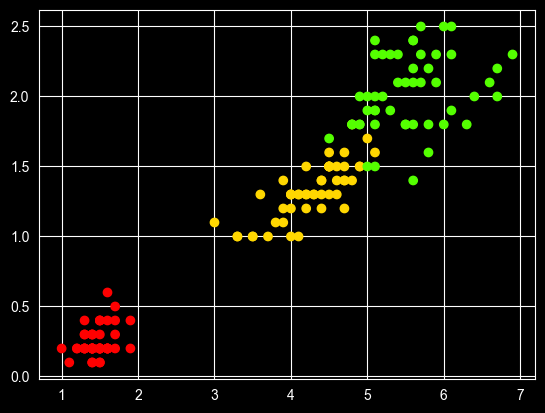

In [41]:
plt.scatter(iris.data["petal length (cm)"], iris.data["petal width (cm)"], c=iris.target, cmap="prism")

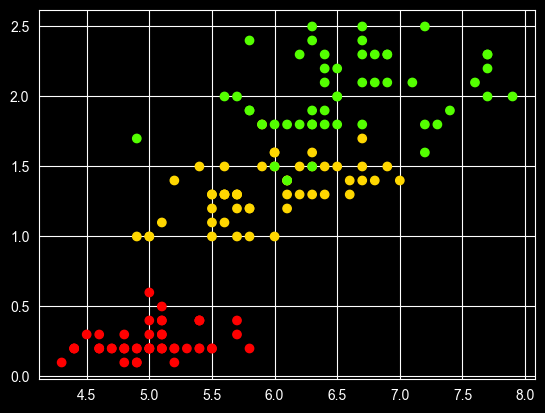

In [42]:
plt.scatter(iris.data["sepal length (cm)"], iris.data["petal width (cm)"], c=iris.target, cmap="prism")

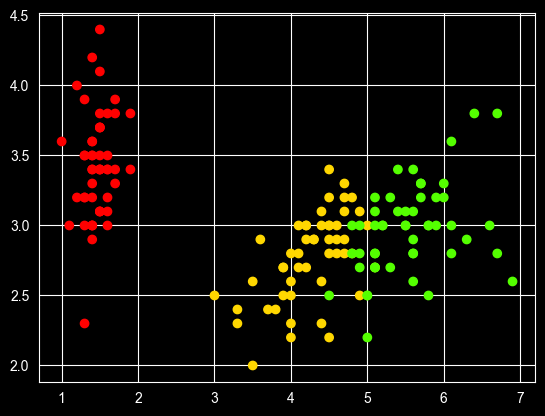

In [43]:
plt.scatter(iris.data["petal length (cm)"], iris.data["sepal width (cm)"], c=iris.target, cmap="prism")

### Model - Logistic Regression

In [44]:
X = iris.data[["petal width (cm)"]].values
X

array([[0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.4],
       [0.3],
       [0.2],
       [0.2],
       [0.1],
       [0.2],
       [0.2],
       [0.1],
       [0.1],
       [0.2],
       [0.4],
       [0.4],
       [0.3],
       [0.3],
       [0.3],
       [0.2],
       [0.4],
       [0.2],
       [0.5],
       [0.2],
       [0.2],
       [0.4],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.4],
       [0.1],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.1],
       [0.2],
       [0.2],
       [0.3],
       [0.3],
       [0.2],
       [0.6],
       [0.4],
       [0.3],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [1.4],
       [1.5],
       [1.5],
       [1.3],
       [1.5],
       [1.3],
       [1.6],
       [1. ],
       [1.3],
       [1.4],
       [1. ],
       [1.5],
       [1. ],
       [1.4],
       [1.3],
       [1.4],
       [1.5],
       [1. ],
       [1.5],
       [1.1],
       [1.8],
      

In [45]:
y = iris.target_names[iris.target] == 'virginica'
y

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 1), (38, 1), (112,), (38,))

In [48]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [57]:
log_reg.intercept_, log_reg.coef_

(array([-6.32263658]), array([[3.83050665]]))

### Decision Boundry

In [59]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
X_new

array([[0.        ],
       [0.003003  ],
       [0.00600601],
       [0.00900901],
       [0.01201201],
       [0.01501502],
       [0.01801802],
       [0.02102102],
       [0.02402402],
       [0.02702703],
       [0.03003003],
       [0.03303303],
       [0.03603604],
       [0.03903904],
       [0.04204204],
       [0.04504505],
       [0.04804805],
       [0.05105105],
       [0.05405405],
       [0.05705706],
       [0.06006006],
       [0.06306306],
       [0.06606607],
       [0.06906907],
       [0.07207207],
       [0.07507508],
       [0.07807808],
       [0.08108108],
       [0.08408408],
       [0.08708709],
       [0.09009009],
       [0.09309309],
       [0.0960961 ],
       [0.0990991 ],
       [0.1021021 ],
       [0.10510511],
       [0.10810811],
       [0.11111111],
       [0.11411411],
       [0.11711712],
       [0.12012012],
       [0.12312312],
       [0.12612613],
       [0.12912913],
       [0.13213213],
       [0.13513514],
       [0.13813814],
       [0.141

In [60]:
y_proba = log_reg.predict_proba(X_new)
y_proba

array([[0.99820801, 0.00179199],
       [0.99818732, 0.00181268],
       [0.99816638, 0.00183362],
       ...,
       [0.00578965, 0.99421035],
       [0.00572381, 0.99427619],
       [0.00565872, 0.99434128]], shape=(1000, 2))

In [61]:
y_proba[:, 1]

array([0.00179199, 0.00181268, 0.00183362, 0.00185479, 0.00187621,
       0.00189787, 0.00191979, 0.00194196, 0.00196438, 0.00198706,
       0.00201   , 0.00203321, 0.00205669, 0.00208043, 0.00210445,
       0.00212875, 0.00215332, 0.00217818, 0.00220332, 0.00222876,
       0.00225449, 0.00228051, 0.00230683, 0.00233346, 0.00236039,
       0.00238764, 0.00241519, 0.00244307, 0.00247126, 0.00249978,
       0.00252863, 0.00255781, 0.00258733, 0.00261718, 0.00264738,
       0.00267793, 0.00270883, 0.00274008, 0.00277169, 0.00280367,
       0.00283601, 0.00286873, 0.00290182, 0.0029353 , 0.00296916,
       0.00300341, 0.00303805, 0.00307309, 0.00310853, 0.00314438,
       0.00318065, 0.00321733, 0.00325443, 0.00329195, 0.00332991,
       0.00336831, 0.00340715, 0.00344643, 0.00348616, 0.00352635,
       0.00356701, 0.00360813, 0.00364972, 0.00369179, 0.00373434,
       0.00377738, 0.00382092, 0.00386495, 0.00390949, 0.00395454,
       0.00400011, 0.0040462 , 0.00409282, 0.00413998, 0.00418

In [62]:
y_proba[:, 1] >=0.5

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [63]:
X_new[y_proba[:, 1] >= 0.5]

array([[1.65165165],
       [1.65465465],
       [1.65765766],
       [1.66066066],
       [1.66366366],
       [1.66666667],
       [1.66966967],
       [1.67267267],
       [1.67567568],
       [1.67867868],
       [1.68168168],
       [1.68468468],
       [1.68768769],
       [1.69069069],
       [1.69369369],
       [1.6966967 ],
       [1.6996997 ],
       [1.7027027 ],
       [1.70570571],
       [1.70870871],
       [1.71171171],
       [1.71471471],
       [1.71771772],
       [1.72072072],
       [1.72372372],
       [1.72672673],
       [1.72972973],
       [1.73273273],
       [1.73573574],
       [1.73873874],
       [1.74174174],
       [1.74474474],
       [1.74774775],
       [1.75075075],
       [1.75375375],
       [1.75675676],
       [1.75975976],
       [1.76276276],
       [1.76576577],
       [1.76876877],
       [1.77177177],
       [1.77477477],
       [1.77777778],
       [1.78078078],
       [1.78378378],
       [1.78678679],
       [1.78978979],
       [1.792

In [69]:
X_new[y_proba[:, 1] >= 0.5].min()


np.float64(1.6516516516516517)

In [70]:
decision_boundary = X_new[y_proba[:, 1] >= 0.5].min()
decision_boundary

np.float64(1.6516516516516517)

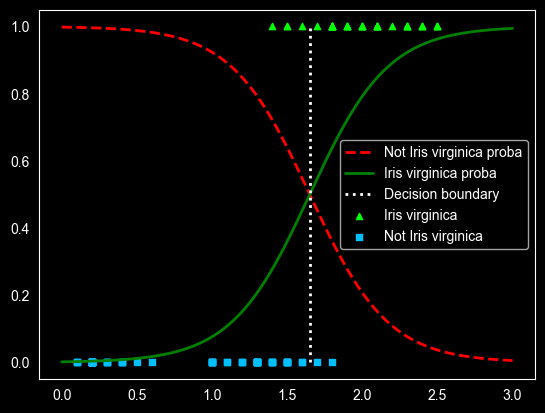

In [168]:
plt.plot(X_new, y_proba[:, 0], "r--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "w:", linewidth=2, label="Decision boundary")
plt.scatter(X_train[y_train], np.ones(np.sum(y_train)), marker="^", s=20, color="lime", label="Iris virginica")
plt.scatter(X_train[~y_train], np.zeros(np.sum(~y_train)), marker="s", s=20, color="deepskyblue", label="Not Iris virginica")
plt.legend()
plt.grid()
plt.show()

In [75]:
decision_boundary

np.float64(1.6516516516516517)

In [109]:
log_reg.predict([[1.5], [1.6], [1.7]]), log_reg.predict_proba([[1.5], [1.6], [1.7]])[:,1]

(array([False, False,  True]), array([0.3596516 , 0.45169465, 0.54716553]))

In [111]:
log_reg.predict([[1.64], [1.65], [1.66]]), log_reg.predict_proba([[1.64], [1.65], [1.66]])[:,1]

(array([False, False,  True]), array([0.48984998, 0.49942485, 0.50900014]))

### Softmax Function & Cross Entropy

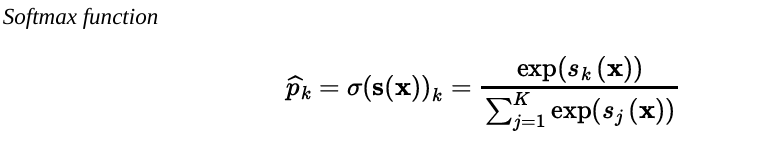

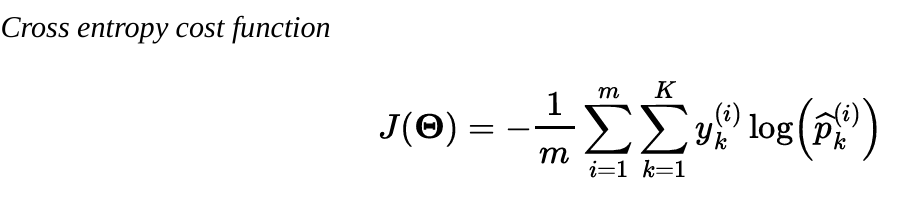

### MultiClass Logistic Regression - Softmax Regression/Multinomial Logistic Regression

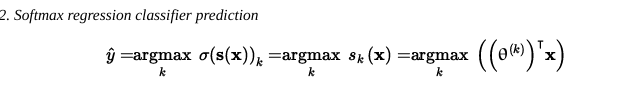

End